In [1]:
import os
import torch
import torch.nn as nn
import pickle
import numpy as np
import base64
from io import BytesIO
from PIL import Image
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# If you have the explainers_lib installed locally, keep this. 
# Otherwise, I have included a simple grouping function below.
import sys
sys.path.append(os.path.abspath('../src'))
from explainers_lib.ensemble import cfs_group_by_original_data
from explainers_lib.aggregators import IdealPoint, TOPSIS, BalancedPoint, ParetoMeanPoint, RandomPoint

# Force CPU
device = torch.device('cpu')
print(f'Using device: {device}')

# ---------------------------------------------------------
# 1. MINIMAL MODEL DEFINITIONS (Decoder Only)
# ---------------------------------------------------------
class TransConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(0.2)
        )
    def forward(self, x):
        return self.block(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 512 * 2 * 2),
            nn.Tanh()
        )
        self.decoder = nn.Sequential(
            TransConvBlock(512, 512),   # 2 → 4
            TransConvBlock(512, 512),   # 4 → 8
            TransConvBlock(512, 256),   # 8 → 16
            TransConvBlock(256, 128),   # 16 → 32
            TransConvBlock(128, 64),    # 32 → 64
            TransConvBlock(64, 32),     # 64 → 128
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 512, 2, 2)
        x = self.decoder(x)
        return x

# Initialize and load weights
decoder = Decoder(latent_dim=128).to(device)
weights = torch.load('autoencoder_celeba_best.pth', map_location=device)

# Filter out only the decoder weights from the full autoencoder state dict
decoder_weights = {k[len('decoder.'):]: v for k, v in weights.items() if k.startswith('decoder.')}
decoder.load_state_dict(decoder_weights)
decoder.eval()

# ---------------------------------------------------------
# 2. LOAD SAVED COUNTERFACTUALS
# ---------------------------------------------------------
PICKLE_FILE_PATH = "results/evaluate_selectors_celeba_20260313_071238.pkl"

with open(PICKLE_FILE_PATH, "rb") as f:
    all_generated_cfes = pickle.load(f)

print(f"Successfully loaded {len(all_generated_cfes)} counterfactuals.")

# Group them by original instance
grouped_cfs = cfs_group_by_original_data(all_generated_cfes)

Using device: cpu
Successfully loaded 391 counterfactuals.


In [2]:
selectors = {
    "RandomPoint": RandomPoint(seed = 42),
    "IdealPoint": IdealPoint(),
    "BalancedPoint": BalancedPoint(),
    "TOPSIS": TOPSIS(k=1),
    "ParetoMeanPoint": ParetoMeanPoint(),
}

with open("results/evaluate_selectors_celeba_20260313_154313_scores.pkl", "rb") as f:
    scores = pickle.load(f)
    scores_map = scores["scores_map"]
    results_by_selector = scores["results_by_selector"]

In [3]:
class_map = {0: "No Smile", 1: "Smile"}
metrics_to_show = ['Proximity', 'K_Feasibility(3)', 'DiscriminativePower(9)']

def image_to_base64(img_array):
    img_uint8 = np.clip(img_array * 255, 0, 255).astype(np.uint8)
    img_pil = Image.fromarray(img_uint8)
    buffered = BytesIO()
    img_pil.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{img_str}"

def precompute_cfe_data(grouped_cfs, decoder, device, metrics_to_show):
    """Decodes images and extracts metrics into a fast, render-ready dictionary."""
    precomputed = []
    
    for orig_id, cfes in tqdm(grouped_cfs.items()):
        if not cfes: continue
        
        # 1. Process Original Image
        with torch.no_grad():
            latent_orig = torch.tensor(cfes[0].original_data, dtype=torch.float32, device=device).unsqueeze(0)
            img_orig = decoder(latent_orig).cpu().squeeze().permute(1, 2, 0).numpy()
            img_orig = (img_orig + 1) / 2
            
        orig_b64 = image_to_base64(img_orig)
        orig_label = class_map.get(cfes[0].original_class, cfes[0].original_class)
        
        cf_list = []
        
        # 2. Process CFEs
        for cf in cfes:
            with torch.no_grad():
                latent_cf = torch.tensor(cf.data, dtype=torch.float32, device=device).unsqueeze(0)
                img_cf = decoder(latent_cf).cpu().squeeze().permute(1, 2, 0).numpy()
                img_cf = (img_cf + 1) / 2
            
            cf_b64 = image_to_base64(img_cf)
            cf_label = class_map.get(cf.target_class, cf.target_class)
            
            scores = scores_map.get(cf.data.tobytes(), {})
            cf_metrics = {m: scores.get(m, 'N/A') for m in metrics_to_show}
            l2_dist = np.linalg.norm(cf.original_data - cf.data)
            selected_by = [selector for selector, cfs in results_by_selector.items() if cf.data.tobytes() in cfs]
            
            cf_list.append({
                'b64': cf_b64,
                'label': cf_label,
                'explainer': cf.explainer[:20],
                'metrics': cf_metrics,
                'l2': l2_dist,
                'selected_by': selected_by
            })
            
        precomputed.append({
            'orig_b64': orig_b64,
            'orig_label': orig_label,
            'cfes': cf_list
        })
        
    return precomputed

precomputed_data = precompute_cfe_data(grouped_cfs, decoder, device, metrics_to_show)

100%|██████████| 19/19 [00:25<00:00,  1.37s/it]


In [4]:
# Define constraints
cherry_picked_ids = [1, 5, 7, 13, 15]
allowed_selectors = ["RandomPoint", "IdealPoint", "BalancedPoint", "TOPSIS"]

records = []

for instance_idx, data in enumerate(precomputed_data):
    cfs = data.get('cfes', [])
    if not cfs:
        continue
        
    target_class = cfs[0].get('label')
    
    for cf in cfs:
        explainer_raw = cf.get('explainer', 'Unknown')
        explainer_name = explainer_raw.split('(')[0].replace('_explainer', '')
        
        selected_by = [s for s in cf.get('selected_by', []) if s in allowed_selectors]
        metrics = cf.get('metrics', {})
        
        row_base = {
            'InstanceID': instance_idx,
            'Explainer': explainer_name,
            'SelectedBy': selected_by,
            'Proximity': float(cf.get('l2', metrics.get('Proximity', np.nan))),
            'K_Feasibility(3)': float(metrics.get('K_Feasibility(3)', np.nan)),
            'DiscriminativePower(9)': float(metrics.get('DiscriminativePower(9)', np.nan))
        }
        
        # 1. Always add to Total Data if target is Smile
        if target_class == "Smile":
            row_total = row_base.copy()
            row_total['Dataset'] = "Total Data (Target=Smile)"
            records.append(row_total)
            
        # 2. Add to Cherry-Picked if it matches our target IDs
        if instance_idx in cherry_picked_ids:
            row_cherry = row_base.copy()
            row_cherry['Dataset'] = "Cherry-Picked (IDs 1,5,7,13,15)"
            records.append(row_cherry)

df_all_cfs = pd.DataFrame(records)
df_all_cfs = df_all_cfs.dropna(subset=['Proximity', 'K_Feasibility(3)', 'DiscriminativePower(9)'])

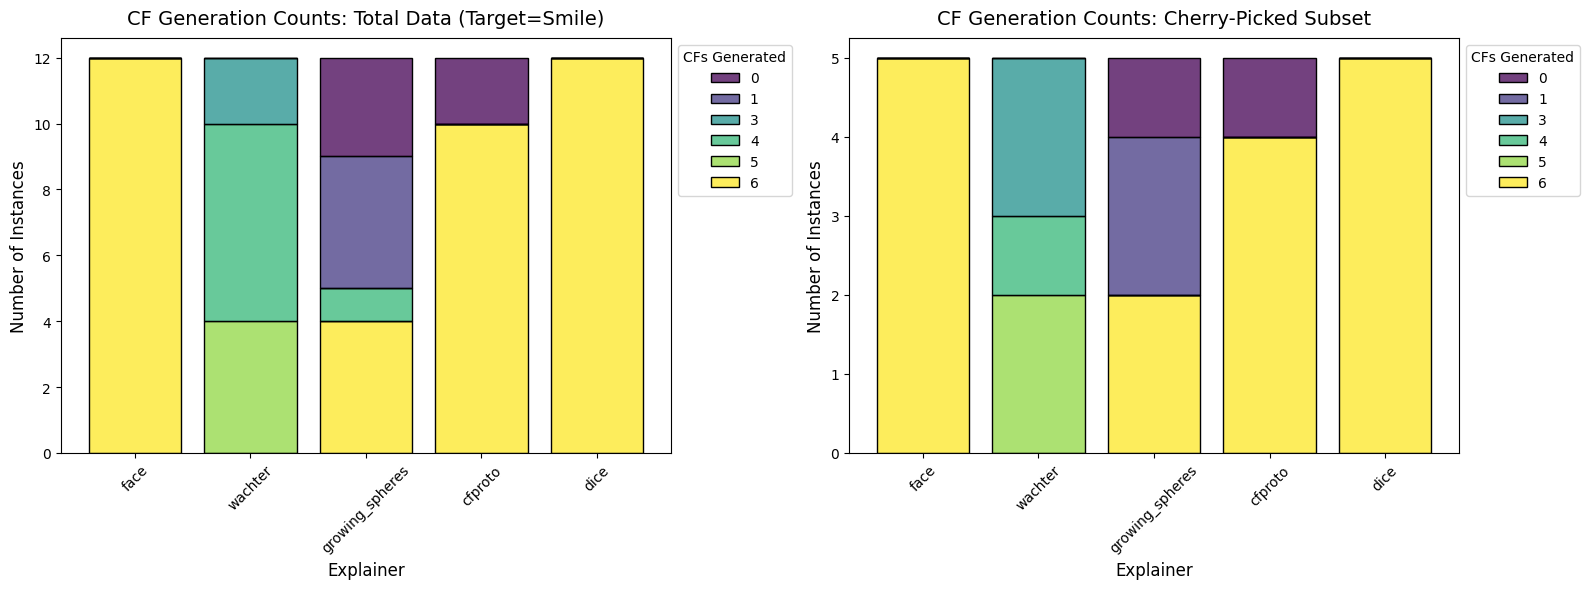

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

unique_explainers = set()
for data in precomputed_data:
    for cf in data.get('cfes', []):
        raw_name = cf.get('explainer', 'Unknown')
        unique_explainers.add(str(raw_name).split('(')[0].replace('_explainer', ''))

counts_data = []

for i, data in enumerate(precomputed_data):
    cfs = data.get('cfes', [])
    if not cfs:
        continue
        
    target_class = cfs[0].get('label')
    
    # Count CFs per explainer for this instance
    current_instance_counts = {name: 0 for name in unique_explainers}
    for cf in cfs:
        raw_name = cf.get('explainer', 'Unknown')
        clean_name = str(raw_name).split('(')[0].replace('_explainer', '')
        current_instance_counts[clean_name] += 1
        
    # 1. Add to Total Data if target is Smile
    if target_class == "Smile":
        for explainer, count in current_instance_counts.items():
            counts_data.append({
                "Instance": i, 
                "Explainer": explainer, 
                "Count": count,
                "Dataset": "Total Data (Target=Smile)"
            })
            
    # 2. Add to Cherry-Picked if it matches our IDs
    if i in cherry_picked_ids:
        for explainer, count in current_instance_counts.items():
            counts_data.append({
                "Instance": i, 
                "Explainer": explainer, 
                "Count": count,
                "Dataset": "Cherry-Picked Subset"
            })

df_counts = pd.DataFrame(counts_data)

# Plotting Side-by-Side Stacked Histograms
datasets = df_counts['Dataset'].unique()
fig, axes = plt.subplots(1, len(datasets), figsize=(16, 6), sharey=False)

if len(datasets) == 1:
    axes = [axes]

max_count = int(df_counts['Count'].max())

for ax, dataset_name in zip(axes, datasets):
    subset = df_counts[df_counts['Dataset'] == dataset_name]
    
    sns.histplot(
        data=subset, x='Explainer', hue='Count', multiple='stack', 
        palette='viridis', discrete=True, shrink=0.8, ax=ax,
        hue_order=range(max_count, -1, -1) 
    )
    
    ax.set_title(f"CF Generation Counts: {dataset_name}", fontsize=14, pad=10)
    ax.set_ylabel("Number of Instances", fontsize=12)
    ax.set_xlabel("Explainer", fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    
    old_legend = ax.get_legend()
    if old_legend:
        old_legend.set_title("CFs Generated")
        sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

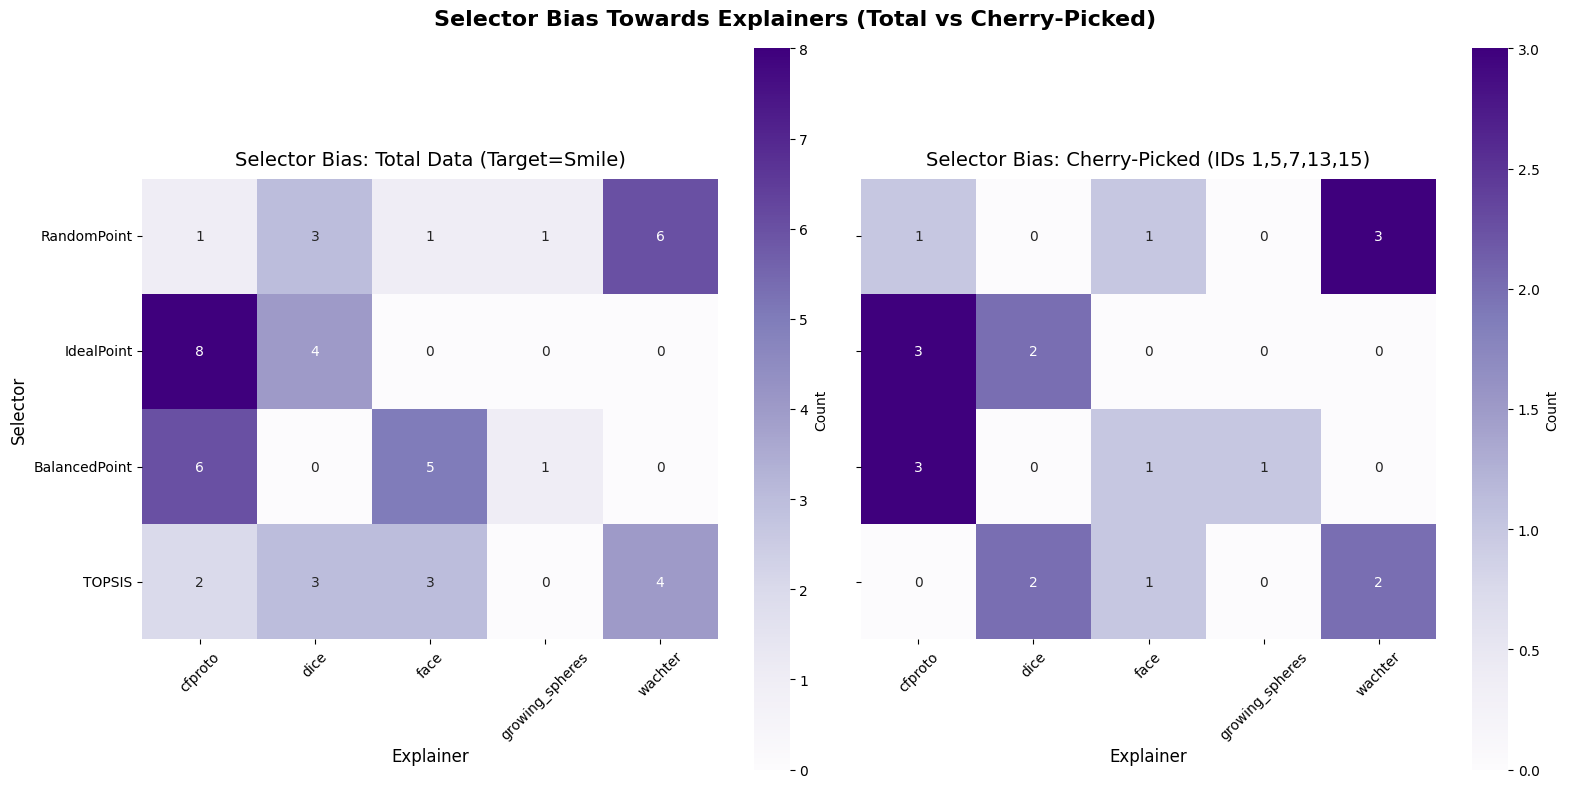

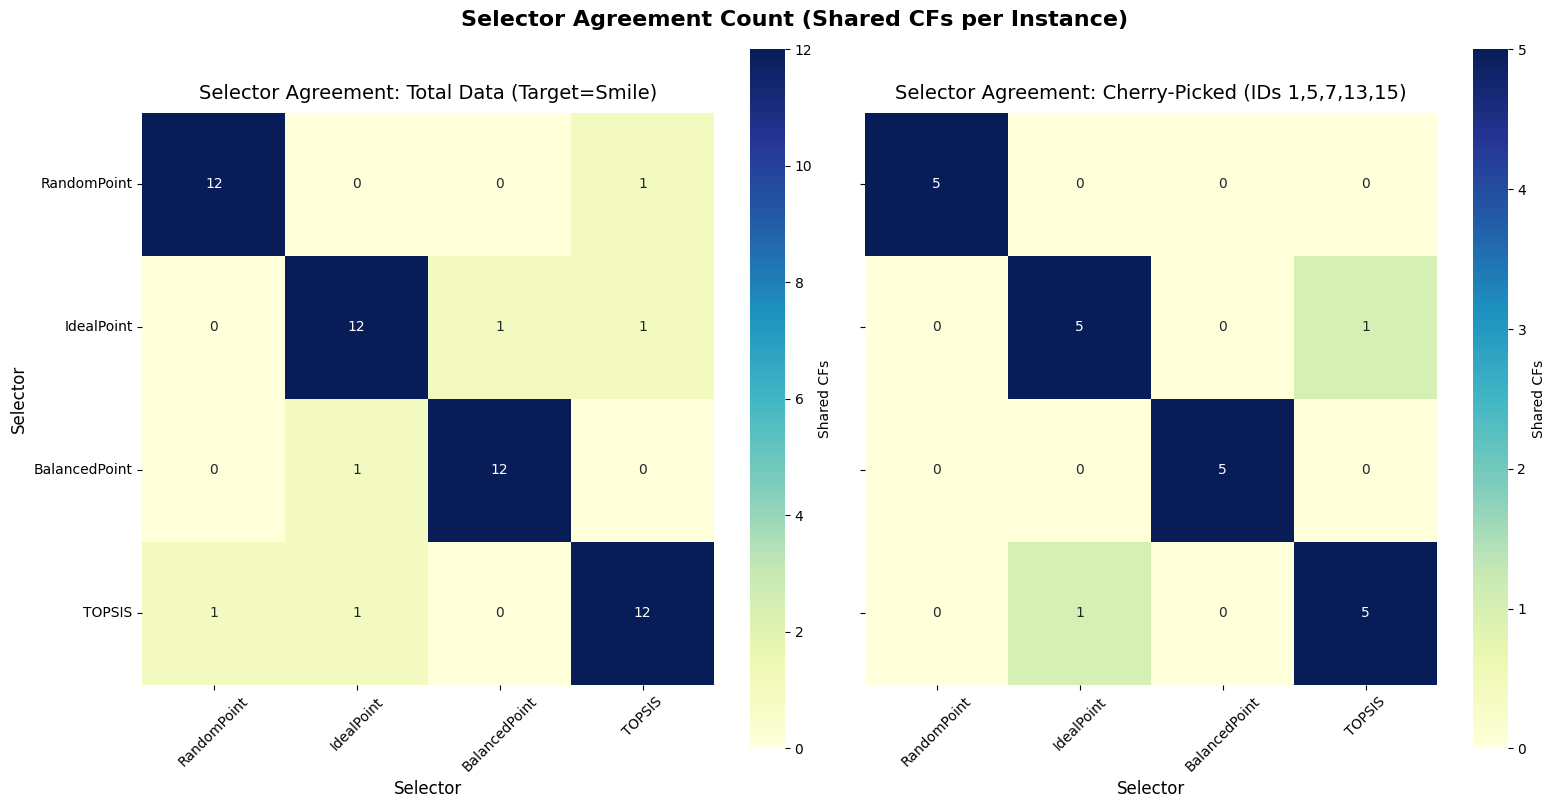

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datasets = df_all_cfs['Dataset'].unique()

fig_bias, axes_bias = plt.subplots(1, len(datasets), figsize=(16, 8), sharey=True)
fig_agree, axes_agree = plt.subplots(1, len(datasets), figsize=(16, 8), sharey=True)

if len(datasets) == 1:
    axes_bias = [axes_bias]
    axes_agree = [axes_agree]

for i, dataset_name in enumerate(datasets):
    subset = df_all_cfs[df_all_cfs['Dataset'] == dataset_name]
    
    bias_records = []
    agreement_matrix = pd.DataFrame(0, index=allowed_selectors, columns=allowed_selectors)
    
    # Group by InstanceID to prevent double-counting duplicate CFEs
    for instance_id, instance_df in subset.groupby('InstanceID'):
        
        # 1. Prepare Data for Selector Bias
        for sel in allowed_selectors:
            # Find rows where this selector successfully picked a CF
            rows_with_sel = instance_df[instance_df['SelectedBy'].apply(lambda lst: sel in lst)]
            if not rows_with_sel.empty:
                # If multiple explainers generated the exact same CF, take the first one 
                # (This mimics the behavior of your original next() function)
                first_explainer = rows_with_sel.iloc[0]['Explainer']
                bias_records.append({'Selector': sel, 'Explainer': first_explainer})
        
        # 2. Prepare Data for Selector Agreement
        for s1 in allowed_selectors:
            for s2 in allowed_selectors:
                # They agree if they BOTH appear in the 'SelectedBy' list of the SAME CF row
                agreed = any((s1 in row['SelectedBy']) and (s2 in row['SelectedBy']) for _, row in instance_df.iterrows())
                if agreed:
                    agreement_matrix.loc[s1, s2] += 1
                    
    # --- Plot Bias Heatmap ---
    if bias_records:
        df_bias = pd.DataFrame(bias_records)
        bias_table = pd.crosstab(df_bias['Selector'], df_bias['Explainer'])
    else:
        bias_table = pd.DataFrame(0, index=allowed_selectors, columns=[])
        
    bias_table = bias_table.reindex(allowed_selectors, fill_value=0)
    
    sns.heatmap(bias_table, annot=True, fmt="d", cmap="Purples", ax=axes_bias[i], 
                cbar_kws={'label': 'Count'}, square=True)
                
    axes_bias[i].set_title(f"Selector Bias: {dataset_name}", fontsize=14, pad=10)
    axes_bias[i].set_xlabel("Explainer", fontsize=12)
    axes_bias[i].tick_params(axis='x', rotation=45) 
    
    if i == 0:
        axes_bias[i].set_ylabel("Selector", fontsize=12)
        axes_bias[i].tick_params(axis='y', rotation=0)
    else:
        axes_bias[i].set_ylabel("")

    # --- Plot Agreement Heatmap ---
    sns.heatmap(agreement_matrix, annot=True, fmt="d", cmap="YlGnBu", ax=axes_agree[i], 
                cbar_kws={'label': 'Shared CFs'}, square=True)
                
    axes_agree[i].set_title(f"Selector Agreement: {dataset_name}", fontsize=14, pad=10)
    axes_agree[i].set_xlabel("Selector", fontsize=12)
    axes_agree[i].tick_params(axis='x', rotation=45)
    
    if i == 0:
        axes_agree[i].set_ylabel("Selector", fontsize=12)
        axes_agree[i].tick_params(axis='y', rotation=0)
    else:
        axes_agree[i].set_ylabel("")

fig_bias.suptitle("Selector Bias Towards Explainers (Total vs Cherry-Picked)", fontsize=16, fontweight='bold')
fig_bias.tight_layout()

fig_agree.suptitle("Selector Agreement Count (Shared CFs per Instance)", fontsize=16, fontweight='bold')
fig_agree.tight_layout()

plt.show()

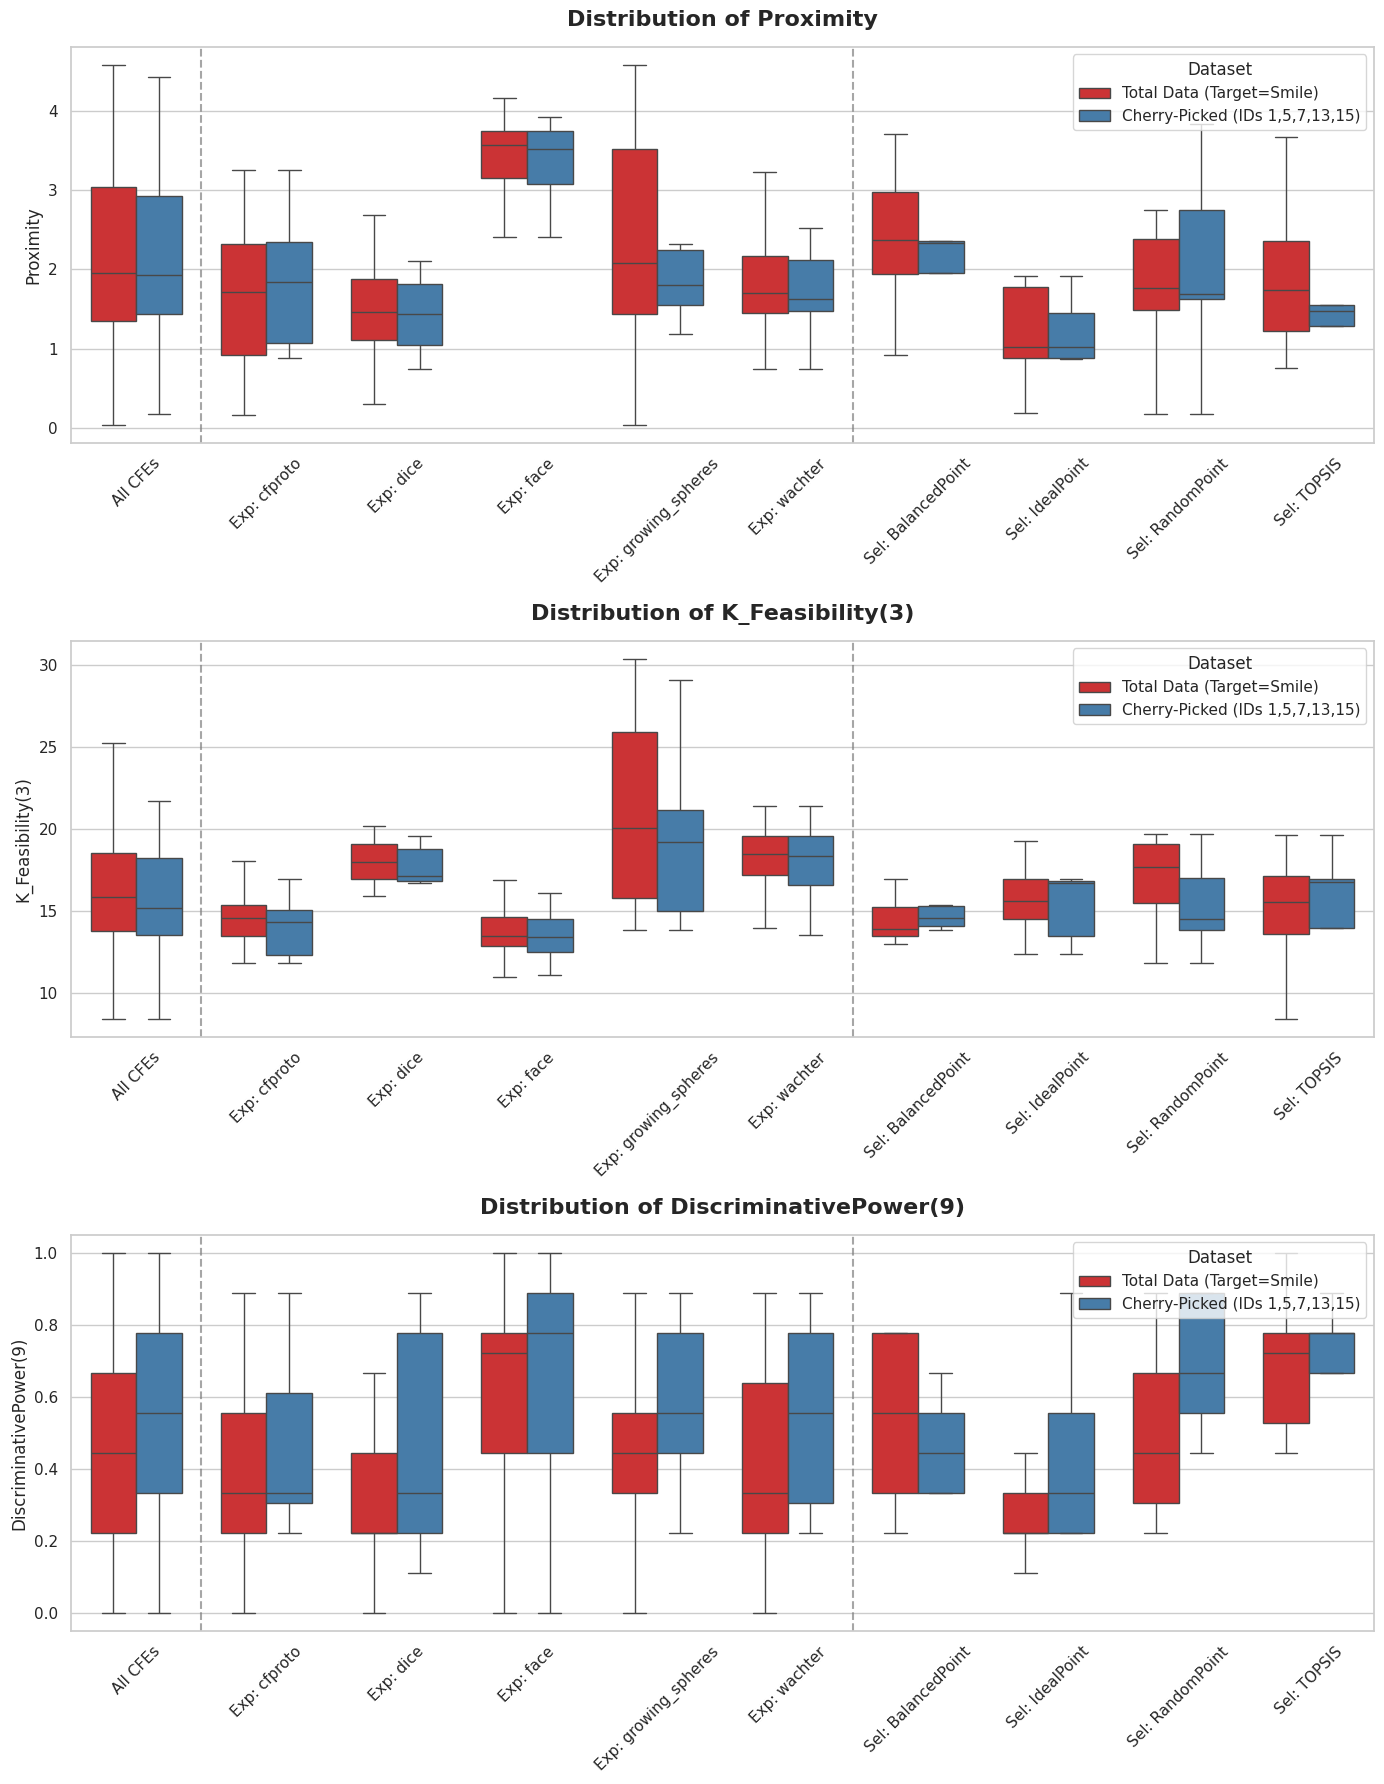

In [7]:
metrics_to_plot = ['Proximity', 'K_Feasibility(3)', 'DiscriminativePower(9)']

# We need to expand the dataframe to match the "Baseline vs Explainers vs Selectors" grouping
plot_records = []

for _, row in df_all_cfs.iterrows():
    base_dict = {
        'Dataset': row['Dataset'],
        'Proximity': row['Proximity'],
        'K_Feasibility(3)': row['K_Feasibility(3)'],
        'DiscriminativePower(9)': row['DiscriminativePower(9)']
    }
    
    # 1. Baseline (All CFs)
    plot_records.append({**base_dict, 'Group': 'All CFEs', 'Category': 'Baseline'})
    
    # 2. Explainers
    plot_records.append({**base_dict, 'Group': f"Exp: {row['Explainer']}", 'Category': 'Explainers'})
    
    # 3. Selectors (Only add if this specific CF was chosen by a selector)
    for selector in row['SelectedBy']:
        plot_records.append({**base_dict, 'Group': f"Sel: {selector}", 'Category': 'Selectors'})

df_boxplot = pd.DataFrame(plot_records)
df_boxplot = df_boxplot.sort_values(by=['Category', 'Group'])

# Plot setup
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(14, 6 * len(metrics_to_plot)))
if len(metrics_to_plot) == 1: axes = [axes]

for i, m in enumerate(metrics_to_plot):
    ax = axes[i]
    
    sns.boxplot(
        data=df_boxplot, x='Group', y=m, hue='Dataset', 
        ax=ax, showfliers=False, width=0.7, palette="Set1"
    )
    
    ax.set_title(f"Distribution of {m}", fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel("")
    ax.set_ylabel(m, fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=11)
    ax.legend(title='Dataset', loc='upper right')

    # Draw vertical separator lines
    baseline_count = len(df_boxplot[df_boxplot['Category'] == 'Baseline']['Group'].unique())
    explainer_count = len(df_boxplot[df_boxplot['Category'] == 'Explainers']['Group'].unique())
    
    if baseline_count > 0:
        ax.axvline(x=baseline_count - 0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    if explainer_count > 0:
        ax.axvline(x=baseline_count + explainer_count - 0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

plt.tight_layout()
plt.show()